# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [1]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-23 21:57:38.099604: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 21:57:38.102170: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 21:57:38.137372: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 21:57:38.137423: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 21:57:38.137453: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

Python executable: /home/Brayden/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [2]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [4]:
from pathlib import Path
def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    # Load training data
    X_train = np.loadtxt(root_dir / "train" / "X_train.txt", dtype=np.float32)
    y_train = np.loadtxt(root_dir / "train" / "y_train.txt", dtype=np.int32) - 1

    # Load test data
    X_test = np.loadtxt(root_dir / "test" / "X_test.txt", dtype=np.float32)
    y_test = np.loadtxt(root_dir / "test" / "y_test.txt", dtype=np.int32) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection

In [5]:
import pandas as pd
import numpy as np

class_counts = np.bincount(y_train)

summary_table = pd.DataFrame({
    "Class Index": np.arange(len(class_names)),
    "Class Name": class_names,
    "Train Samples": class_counts
})

summary_table

,Class Index,Class Name,Train Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:

def build_baseline_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2026-04-23 21:59:29.506605: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


### Train the Baseline Model

In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40
92/92 [==============================] - 1s 8ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 1s 6ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 0s 5ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0748 - accuracy: 0.9711 - val_loss: 0.2056 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0765 - accuracy: 0.9716 - val_loss: 0.1482 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves

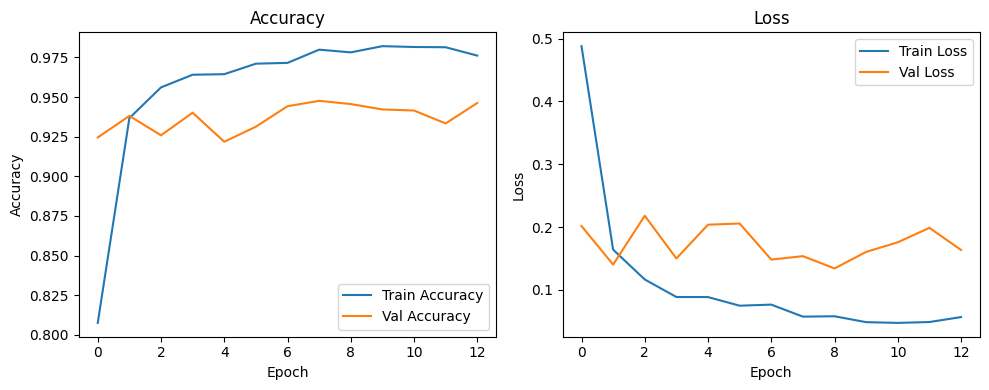

In [8]:
import matplotlib.pyplot as plt

# 1. Accuracy plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# 2. Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 3ms/step
Test Accuracy: 0.9219545300305395
                    precision    recall  f1-score   support

           WALKING       0.95      0.94      0.94       496
  WALKING_UPSTAIRS       0.95      0.90      0.92       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.98      0.80      0.88       491
          STANDING       0.81      0.98      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



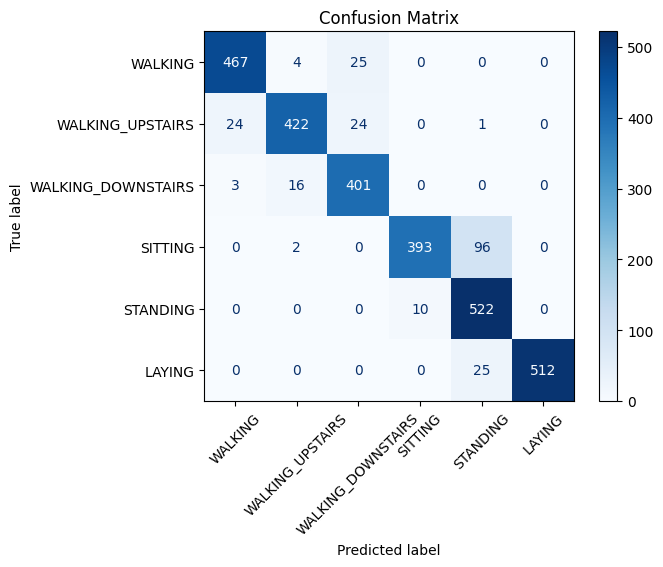

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Predict probabilities
y_probs = baseline_model.predict(X_test)

# 2. Convert probabilities to class labels
y_pred = np.argmax(y_probs, axis=1)

# 3. Accuracy
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

# 4. Classification report
print(classification_report(y_test, y_pred, target_names=class_names))

# 5. Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()


# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [11]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # Input quantization
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # Output dequantization
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    return tflite_model


## 8. Convert the Baseline Model to TensorFlow Lite

In [12]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

# <-- Enter your code here <--#
# Convert to FP32 TFLite
fp32_tflite = tf.lite.TFLiteConverter.from_keras_model(baseline_model).convert()

# Save model + compute size
fp32_size_kb = save_binary_model(fp32_tflite, "baseline_fp32.tflite")

# Evaluate on test set
fp32_acc, fp32_preds = evaluate_tflite_model(fp32_tflite, X_test, y_test)

print(f"FP32 TFLite Accuracy: {fp32_acc:.4f}")
print(f"FP32 TFLite Size (KB): {fp32_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmpqz6fcewh/assets


INFO:tensorflow:Assets written to: /tmp/tmpqz6fcewh/assets


FP32 TFLite Accuracy: 0.9220
FP32 TFLite Size (KB): 726.72


2026-04-23 22:01:31.008183: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:01:31.008221: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:01:31.008680: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpqz6fcewh
2026-04-23 22:01:31.009882: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:01:31.009893: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpqz6fcewh
2026-04-23 22:01:31.012766: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-23 22:01:31.013667: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:01:31.071580: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpqz6fcewh
2026-04

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [13]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

# <-- Enter your code here <--#

steps_per_epoch = int(0.8 * len(X_train)) // batch_size

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#

# Create fresh baseline model
pruned_model = prune_low_magnitude(
    build_baseline_model(num_features, num_classes),
    **pruning_params
)

# Compile model
pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

# <-- Enter your code here <--#

pruned_history = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)


Epoch 1/12
92/92 [==============================] - 3s 9ms/step - loss: 0.4751 - accuracy: 0.8067 - val_loss: 0.2226 - val_accuracy: 0.9218
Epoch 2/12
92/92 [==============================] - 1s 6ms/step - loss: 0.1662 - accuracy: 0.9395 - val_loss: 0.1603 - val_accuracy: 0.9279
Epoch 3/12
92/92 [==============================] - 0s 5ms/step - loss: 0.1308 - accuracy: 0.9517 - val_loss: 0.2274 - val_accuracy: 0.9266
Epoch 4/12
92/92 [==============================] - 0s 5ms/step - loss: 0.0924 - accuracy: 0.9685 - val_loss: 0.1644 - val_accuracy: 0.9334
Epoch 5/12
92/92 [==============================] - 0s 5ms/step - loss: 0.1505 - accuracy: 0.9452 - val_loss: 0.1418 - val_accuracy: 0.9381
Epoch 6/12
92/92 [==============================] - 0s 5ms/step - loss: 0.1465 - accuracy: 0.9503 - val_loss: 0.1410 - val_accuracy: 0.9334
Epoch 7/12
92/92 [==============================] - 0s 5ms/step - loss: 0.3570 - accuracy: 0.9252 - val_loss: 0.1653 - val_accuracy: 0.9361
Epoch 8/12
92/92 [==

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [14]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

# <-- Enter your code here <--#

pruned_with_mask_tflite = tf.lite.TFLiteConverter.from_keras_model(
    pruned_model
).convert()

pruned_with_mask_size_kb = save_binary_model(
    pruned_with_mask_tflite,
    "pruned_with_mask.tflite"
)

pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(
    pruned_with_mask_tflite,
    X_test,
    y_test
)

# Strip pruning wrappers
stripped_model = strip_pruning(pruned_model)

# Convert with sparsity optimization
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]

stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(
    stripped_sparse_tflite,
    "stripped_sparse.tflite"
)

stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(
    stripped_sparse_tflite,
    X_test,
    y_test
)




INFO:tensorflow:Assets written to: /tmp/tmp8mg6z5ff/assets


INFO:tensorflow:Assets written to: /tmp/tmp8mg6z5ff/assets
2026-04-23 22:04:44.753305: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:04:44.753352: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:04:44.753591: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp8mg6z5ff
2026-04-23 22:04:44.757217: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:04:44.757253: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp8mg6z5ff
2026-04-23 22:04:44.768321: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:04:44.839848: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp8mg6z5ff
2026-04-23 22:04:44.862597: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp_v2e4_lp/assets


INFO:tensorflow:Assets written to: /tmp/tmp_v2e4_lp/assets
2026-04-23 22:04:46.597604: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:04:46.597637: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:04:46.597829: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp_v2e4_lp
2026-04-23 22:04:46.598755: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:04:46.598773: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp_v2e4_lp
2026-04-23 22:04:46.600898: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:04:46.622139: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp_v2e4_lp
2026-04-23 22:04:46.631594: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

## 11. Part I Comparison: Accuracy and Model Size

In [15]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

# <-- Enter your code here <--#

import pandas as pd

part1_results = pd.DataFrame([
    ["Baseline TFLite", "FP32", fp32_acc, fp32_size_kb],
    ["Pruned TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part1_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Baseline TFLite,FP32,0.921955,726.718750
1,Pruned TFLite (with mask),FP32,0.908042,1454.175781
2,Stripped Sparse TFLite,FP32 + Sparse,0.908042,194.359375


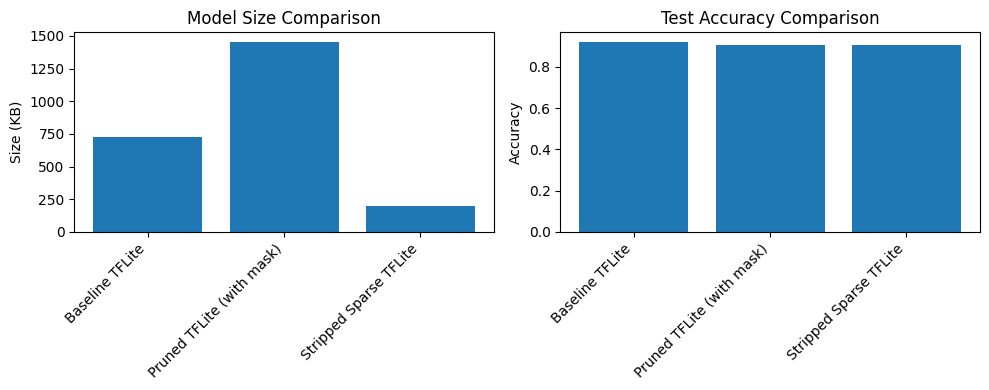

In [17]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

# <-- Enter your code here <--#


# Data
models = part1_results["Model"]
sizes = part1_results["Model Size (KB)"]
accuracies = part1_results["Test Accuracy"]

# 1. Model size plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(models, sizes)
plt.title("Model Size Comparison")
plt.ylabel("Size (KB)")
plt.xticks(rotation=45, ha="right")

# 2. Accuracy plot
plt.subplot(1, 2, 2)
plt.bar(models, accuracies)
plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


### Confusion Matrix for the Stripped Sparse Model

                    precision    recall  f1-score   support

           WALKING       0.98      0.96      0.97       496
  WALKING_UPSTAIRS       0.93      0.94      0.94       471
WALKING_DOWNSTAIRS       0.91      0.93      0.92       420
           SITTING       0.96      0.64      0.77       491
          STANDING       0.75      0.98      0.85       532
            LAYING       1.00      0.99      1.00       537

          accuracy                           0.91      2947
         macro avg       0.92      0.91      0.91      2947
      weighted avg       0.92      0.91      0.91      2947



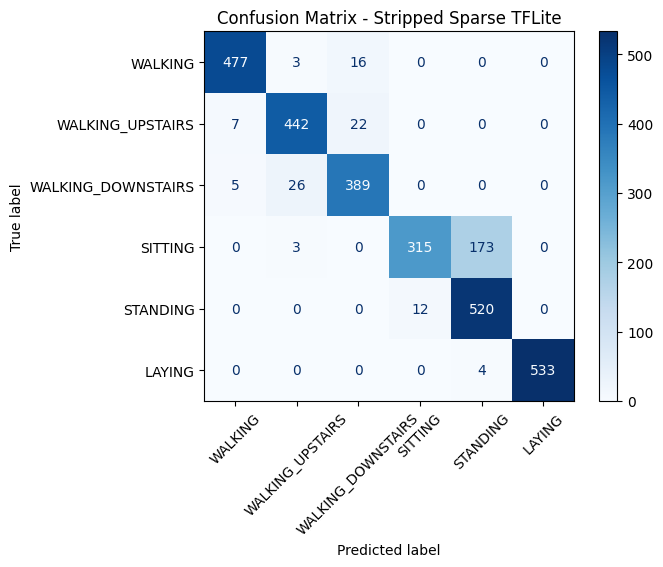

In [18]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

# <-- Enter your code here <--#

# If not already computed, evaluate model again
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(
    stripped_sparse_tflite,
    X_test,
    y_test
)

# Classification report
print(classification_report(
    y_test,
    stripped_sparse_preds,
    target_names=class_names
))

# Confusion matrix
cm = confusion_matrix(y_test, stripped_sparse_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Stripped Sparse TFLite")
plt.show()


# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [20]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

# <-- Enter your code here <--#

converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

pruned_mask_f16_tflite = converter.convert()

pruned_mask_f16_size_kb = save_binary_model(
    pruned_mask_f16_tflite,
    "pruned_mask_float16.tflite"
)

pruned_mask_f16_acc, _ = evaluate_tflite_model(
    pruned_mask_f16_tflite,
    X_test,
    y_test
)

stripped_model = strip_pruning(pruned_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT,
    tf.lite.Optimize.EXPERIMENTAL_SPARSITY
]

converter.target_spec.supported_types = [tf.float16]

stripped_sparse_f16_tflite = converter.convert()

stripped_sparse_f16_size_kb = save_binary_model(
    stripped_sparse_f16_tflite,
    "stripped_sparse_float16.tflite"
)

stripped_sparse_f16_acc, _ = evaluate_tflite_model(
    stripped_sparse_f16_tflite,
    X_test,
    y_test
)


INFO:tensorflow:Assets written to: /tmp/tmp9ppggbrm/assets


INFO:tensorflow:Assets written to: /tmp/tmp9ppggbrm/assets
2026-04-23 22:07:22.148574: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:07:22.148608: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:07:22.148801: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp9ppggbrm
2026-04-23 22:07:22.151781: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:07:22.151835: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp9ppggbrm
2026-04-23 22:07:22.161337: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:07:22.231843: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp9ppggbrm
2026-04-23 22:07:22.254347: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpfcs4i7d6/assets


INFO:tensorflow:Assets written to: /tmp/tmpfcs4i7d6/assets
2026-04-23 22:07:23.520564: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:07:23.520598: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:07:23.520801: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpfcs4i7d6
2026-04-23 22:07:23.521521: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:07:23.521534: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpfcs4i7d6
2026-04-23 22:07:23.523336: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:07:23.543908: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpfcs4i7d6
2026-04-23 22:07:23.551188: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

## 12. Part II Comparison: Accuracy and Model Size

In [21]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

# <-- Enter your code here <--#

part2_results = pd.DataFrame([
    ["Pruned Model (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Model", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Pruned Model (with mask)", "Float16", pruned_mask_f16_acc, pruned_mask_f16_size_kb],
    ["Stripped Sparse Model", "Float16 + Sparse", stripped_sparse_f16_acc, stripped_sparse_f16_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Pruned Model (with mask),FP32,0.908042,1454.175781
1,Stripped Sparse Model,FP32 + Sparse,0.908042,194.359375
2,Pruned Model (with mask),Float16,0.908042,732.585938
3,Stripped Sparse Model,Float16 + Sparse,0.908042,129.250000


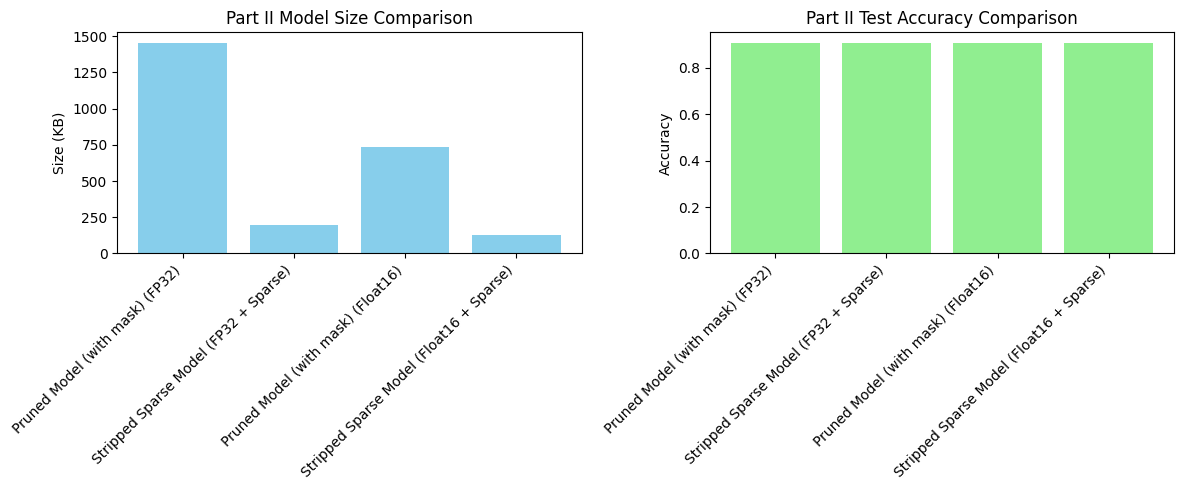

In [23]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

models = part2_results["Model"] + " (" + part2_results["Format"] + ")"
sizes = part2_results["Model Size (KB)"]
accuracies = part2_results["Test Accuracy"]

plt.figure(figsize=(12, 5))

# 1. Model size plot
plt.subplot(1, 2, 1)
plt.bar(models, sizes, color="skyblue")
plt.title("Part II Model Size Comparison")
plt.ylabel("Size (KB)")
plt.xticks(rotation=45, ha="right")

# 2. Accuracy plot
plt.subplot(1, 2, 2)
plt.bar(models, accuracies, color="lightgreen")
plt.title("Part II Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


### Confusion Matrix for the Stripped Sparse + Float16 Model

                    precision    recall  f1-score   support

           WALKING       0.98      0.96      0.97       496
  WALKING_UPSTAIRS       0.93      0.94      0.94       471
WALKING_DOWNSTAIRS       0.91      0.93      0.92       420
           SITTING       0.96      0.64      0.77       491
          STANDING       0.75      0.98      0.85       532
            LAYING       1.00      0.99      1.00       537

          accuracy                           0.91      2947
         macro avg       0.92      0.91      0.91      2947
      weighted avg       0.92      0.91      0.91      2947



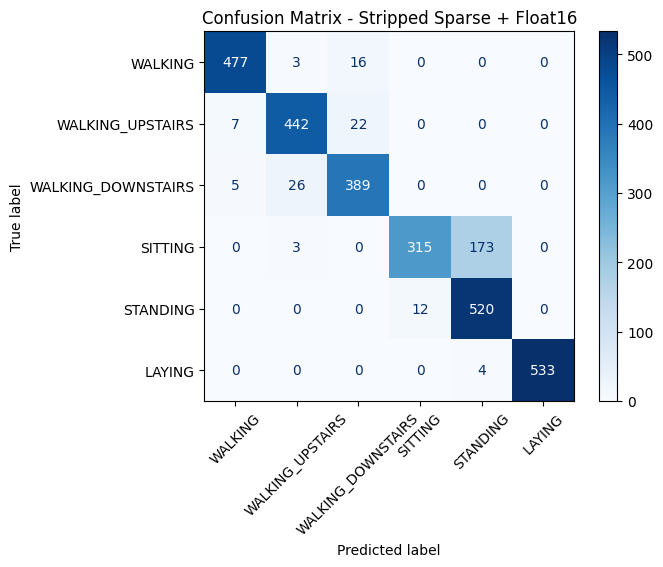

In [24]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

# <-- Enter your code here <--#

# Evaluate model (if not already done)
stripped_sparse_f16_acc, stripped_sparse_f16_preds = evaluate_tflite_model(
    stripped_sparse_f16_tflite,
    X_test,
    y_test
)

# Classification report
print(classification_report(
    y_test,
    stripped_sparse_f16_preds,
    target_names=class_names
))

# Confusion matrix
cm = confusion_matrix(y_test, stripped_sparse_f16_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Stripped Sparse + Float16")
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?
2. Why does `strip_pruning(...)` matter before export?
3. Which model had the smallest file size in this notebook?
4. Did float16 quantization noticeably change the test accuracy?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
